# Explicit Euler 

First order nummerical integration scheme:

$x = x + \Delta t\cdot p/m$

$p = p + \Delta t\cdot f$

In [1]:
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt 

In [6]:
# analytical solution
t = np.linspace(0,2*np.pi,361)
x_exact = np.cos(t)
p_exact = -np.sin(t)

In [69]:
# integration parameters
dt = 0.05  # 0.01, 0.05
num_steps = 200

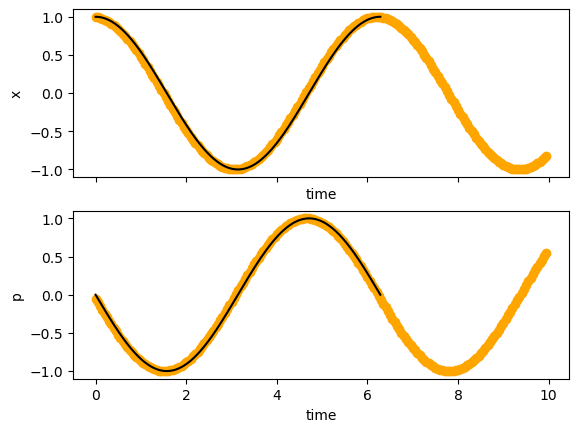

In [70]:
fig,ax = plt.subplots(2,1,sharex=True)
 
class HarmonicForce:
    """Harmonic spring force."""
    def __init__(self, k):
        self.k = k

    def __call__(self, x):
        """Evaluate force at position."""
        return -self.k*x

# initial condition
x = 1.
p = 0.
m = 1.0
force = HarmonicForce(k=1.0)

ee_x = [] 
ee_p = [] 
ee_t = [] 

f = force(x)
for i in range(num_steps):
    # momentum step 
    f = force(x)
    p += dt*f
    
    # position step
    x += dt*(p/m)
    
    ee_x.append(x)
    ee_p.append(p)
    ee_t.append(i*dt)
    
ax[0].scatter(ee_t, ee_x, c='orange')
ax[1].scatter(ee_t, ee_p, c='orange')

# analytical
ax[0].plot(t, x_exact, c='black')
ax[1].plot(t, p_exact, c='black')

ax[0].set_xlabel('time')
ax[0].set_ylabel('x')
ax[1].set_xlabel('time')
ax[1].set_ylabel('p') 

plt.show()

## Velocity Verlet 

The standard implementation scheme of this algorithm is:
1. Calculate  $\mathbf {v} \left(t+{\tfrac {1}{2}}\,\Delta t\right)=\mathbf {v} (t)+{\tfrac {1}{2}}\,\mathbf {a} (t)\,\Delta t.$ (momentum half-step)
2. Calculate 
$ \mathbf {x} (t+\Delta t)=\mathbf {x} (t)+\mathbf {v} \left(t+{\tfrac {1}{2}}\,\Delta t\right)\,\Delta t$. (position full step) 
3. Derive $\mathbf {a} (t+\Delta t)$ from the interaction potential using $\mathbf {x} (t+\Delta t)$.
4. Calculate $\mathbf {v} (t+\Delta t)=\mathbf {v} \left(t+{\tfrac {1}{2}}\,\Delta t\right)+{\tfrac {1}{2}}\,\mathbf {a} (t+\Delta t)\Delta t$. (momentum half step)

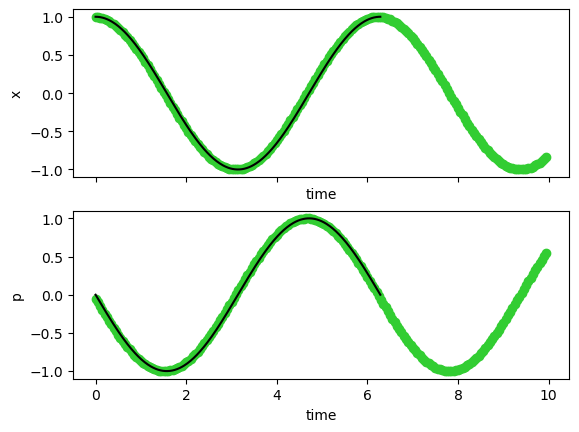

In [73]:
fig,ax = plt.subplots(2,1,sharex=True)

# initial condition
x = 1.
p = 0.
m = 1.0
force = HarmonicForce(k=1.0)

vv_x = [] 
vv_p = [] 
vv_t = [] 

f = force(x)
for i in range(num_steps):
    # momentum half step
    p += 0.5*dt*f
    # position full step
    x += dt*(p/m)
    # momentum half step
    f = force(x)
    p += 0.5*dt*f
    # numerical
    vv_x.append(x)
    vv_p.append(p)
    vv_t.append(i*dt)
    
ax[0].scatter(vv_t, vv_x, c='limegreen')
ax[1].scatter(vv_t, vv_p, c='limegreen')

# analytical
ax[0].plot(t, x_exact, c='black')
ax[1].plot(t, p_exact, c='black')

ax[0].set_xlabel('time')
ax[0].set_ylabel('x')
ax[1].set_xlabel('time')
ax[1].set_ylabel('p')

plt.show()

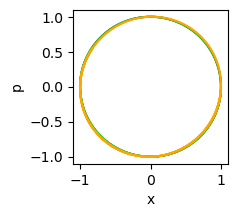

In [74]:
fig,ax = plt.subplots(figsize=(2,2))

ax.plot(x_exact, p_exact, c='black')
ax.plot(vv_x, vv_p, c='limegreen')
ax.plot(ee_x, ee_p, c='orange')

ax.set_xlabel('x')
ax.set_ylabel('p')
plt.show()

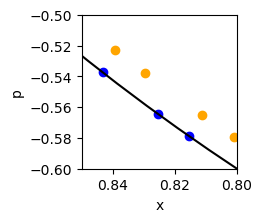

In [75]:
fig,ax = plt.subplots(figsize=(2,2))

ax.plot(x_exact, p_exact, c='black')
ax.scatter(vv_x, vv_p, c='blue')
ax.scatter(ee_x, ee_p, c='orange')

ax.set_ylim([-0.6,-0.5])
ax.set_xlim([0.85,0.8])
ax.set_xlabel('x')
ax.set_ylabel('p')
plt.show()